In [3]:
# Da utilizzare solo quando la cache è piena
# torch.cuda.empty_cache()
# import gc
# gc.collect()
# torch.cuda.empty_cache()

import os
import random
import numpy as np
import pandas as pd
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from torch.nn.functional import softmax

# 1) Riproducibilità
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 2) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 3) Caricamento e preprocessing
df_conv = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/Dataset_Toxic_Conv_4.0_Cleaned.csv',
    sep=';', encoding='latin1', engine='python', on_bad_lines='skip'
)[['conversation','toxic']]
df_conv['toxic'] = (
    df_conv['toxic']
      .fillna('No').str.strip().str.lower()
      .map(lambda x: 1 if x.startswith('s') else 0)
)
df_conv['conversation'] = df_conv['conversation'].astype(str).str.strip().str.strip('"')

df_raw = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/AMI2020_training_raw_anon.tsv',
    sep='\t', encoding='utf-8'
)
label_cols = [c for c in ['misogynous','aggressiveness'] if c in df_raw.columns]
df_raw['toxic'] = df_raw[label_cols].max(axis=1)
df_raw = df_raw[['text','toxic']].rename(columns={'text':'conversation'})

df_synt = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/AMI2020_training_synt.tsv',
    sep='\t', encoding='utf-8'
)[['text','misogynous']].rename(columns={'text':'conversation','misogynous':'toxic'})

df_comments = pd.concat([df_raw, df_synt], ignore_index=True)
df_all      = pd.concat([df_conv, df_comments], ignore_index=True).sample(frac=1, random_state=SEED)

# 4) Split train/val/test
train_df, temp_df = train_test_split(df_all, test_size=0.10, stratify=df_all['toxic'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['toxic'], random_state=SEED)

# 5) Dataset
class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.texts      = df['conversation'].tolist()
        self.labels     = df['toxic'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 6) Tokenizer & modello BERT
MODEL_NAME = 'dbmdz/bert-base-italian-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

# 7) DataLoader
train_loader = DataLoader(ToxicDataset(train_df, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(ToxicDataset(val_df,   tokenizer), batch_size=16)
test_loader  = DataLoader(ToxicDataset(test_df,  tokenizer), batch_size=16)

# 8) Ottimizzazione
optimizer   = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * 5
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps
)

# 9) Funzioni train/val
def train_epoch():
    model.train()
    losses = []
    for b in train_loader:
        optimizer.zero_grad()
        out = model(
            input_ids=b['input_ids'].to(device),
            attention_mask=b['attention_mask'].to(device),
            labels=b['labels'].to(device)
        )
        out.loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(out.loss.item())
    return np.mean(losses)

def eval_epoch():
    model.eval()
    losses = []
    with torch.no_grad():
        for b in val_loader:
            out = model(
                input_ids=b['input_ids'].to(device),
                attention_mask=b['attention_mask'].to(device),
                labels=b['labels'].to(device)
            )
            losses.append(out.loss.item())
    return np.mean(losses)

# 10) Training con early stopping
BEST_VAL_LOSS = float('inf')
PATIENCE      = 2
counter       = 0
MAX_EPOCHS    = 5

for epoch in range(1, MAX_EPOCHS+1):
    tr_loss = train_epoch()
    vl_loss = eval_epoch()
    print(f"Epoch {epoch}/{MAX_EPOCHS} — train_loss: {tr_loss:.4f} — val_loss: {vl_loss:.4f}")
    if vl_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = vl_loss
        counter = 0
        model.save_pretrained('./best_toxic_model')
        tokenizer.save_pretrained('./best_toxic_model')
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping")
            break

# 11) Inference sul test set e raccolta predizioni
model.eval()
all_preds, all_trues = [], []
with torch.no_grad():
    for b in test_loader:
        logits = model(
            input_ids=b['input_ids'].to(device),
            attention_mask=b['attention_mask'].to(device)
        ).logits
        probs = softmax(logits, dim=1)[:,1].cpu().numpy()
        preds = (probs > 0.5).astype(int).tolist()
        all_preds.extend(preds)
        all_trues.extend(b['labels'].tolist())

# 12) Calcolo metriche
acc  = accuracy_score(all_trues, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_trues, all_preds, average='binary', zero_division=0
)
cm = confusion_matrix(all_trues, all_preds)

print(f"\nRisultati sul test set:")
print(f" Accuracy : {acc:.4f}")
print(f" Precision: {prec:.4f}")
print(f" Recall   : {rec:.4f}")
print(f" F1-score : {f1:.4f}")
print(" Confusion matrix:")
print(cm)

# 13) Salvataggio metriche aggregate (append se esiste)
metrics_file = 'metrics_summary.csv'
new_row = pd.DataFrame([{
    'model':     'bert_italian',
    'accuracy':  acc,
    'precision': prec,
    'recall':    rec,
    'f1_score':  f1
}]).set_index('model')

if os.path.exists(metrics_file):
    df_existing = pd.read_csv(metrics_file, index_col=0)
    # evita duplicati
    if 'bert_italian' in df_existing.index:
        df_existing.drop('bert_italian', inplace=True)
    df_updated = pd.concat([df_existing, new_row])
else:
    df_updated = new_row

df_updated.to_csv(metrics_file)
print(f"\nAppended results to {metrics_file}")

# 14) Salvataggio confusion matrix (aggiorna il dict)
cms_file = 'confusion_matrices.pkl'
if os.path.exists(cms_file):
    with open(cms_file, 'rb') as f:
        cms = pickle.load(f)
else:
    cms = {}

cms['bert_italian'] = cm.tolist()
with open(cms_file, 'wb') as f:
    pickle.dump(cms, f)
print(f"Updated {cms_file}")


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-italian-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 — train_loss: 0.3970 — val_loss: 0.1232
Epoch 2/5 — train_loss: 0.1330 — val_loss: 0.0852
Epoch 3/5 — train_loss: 0.0692 — val_loss: 0.0810
Epoch 4/5 — train_loss: 0.0266 — val_loss: 0.0921
Epoch 5/5 — train_loss: 0.0125 — val_loss: 0.0963
Early stopping

Risultati sul test set:
 Accuracy : 0.9531
 Precision: 0.9554
 Recall   : 0.9554
 F1-score : 0.9554
 Confusion matrix:
[[173   9]
 [  9 193]]

Appended results to metrics_summary.csv
Updated confusion_matrices.pkl


In [6]:
import random
import re
import torch
from torch.nn.functional import softmax
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM
)
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# 1) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Carica modello di tossicità
TOXIC_MODEL_DIR = './best_toxic_model'
tox_tok   = AutoTokenizer.from_pretrained(TOXIC_MODEL_DIR, local_files_only=True)
tox_model = AutoModelForSequenceClassification.from_pretrained(
                TOXIC_MODEL_DIR, local_files_only=True
            ).to(device)
tox_model.eval()

# 3) Carica Mistral per spiegazioni
user_secrets = UserSecretsClient()
hf_token     = user_secrets.get_secret("Mistral")  # il tuo token su Kaggle
login(token=hf_token)

MISTRAL_NAME = "mistralai/Mistral-7B-Instruct-v0.1"
mis_tok   = AutoTokenizer.from_pretrained(MISTRAL_NAME)
mis_model = AutoModelForCausalLM.from_pretrained(
                MISTRAL_NAME,
                device_map="auto",
                torch_dtype=torch.float16
            )

# 4) Funzioni utili
def get_toxic_score(text):
    enc = tox_tok(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        logits = tox_model(**enc).logits
    return float(softmax(logits, dim=1)[0,1].cpu())

def explain(utt):
    prompt = f"[INST] Spiega in italiano perché la seguente frase può essere considerata tossica: \"{utt}\" [/INST]"
    enc = mis_tok(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = mis_model.generate(
            **enc,
            max_new_tokens=100,
            pad_token_id=mis_tok.eos_token_id
        )
    return mis_tok.decode(out[0], skip_special_tokens=True)

def split_utterances(conv):
    return [p.strip() for p in re.split(r'(?=[A-Z][a-z]+:)', conv) if p.strip()]

# 5) Prendi 5 conversazioni random dal test set
random.seed(42)
sample_convs = random.sample(test_df['conversation'].tolist(), 5)

# 6) Inferenza + spiegazione
for conv in sample_convs:
    print("\n➤ Conversazione:")
    print(conv, "\n")

    score = get_toxic_score(conv)
    label = "Tossica" if score>0.5 else "Non tossica"
    print(f"→ Predizione: {label} (score: {score:.4f})")

    if score > 0.5:
        uts = split_utterances(conv)
        toxic_uts = [(u, get_toxic_score(u)) for u in uts if get_toxic_score(u)>0.5]
        if toxic_uts:
            for utt, sc in toxic_uts:
                print(f"\n  • Frase tossica: {utt} (score: {sc:.4f})")
                explanation = explain(utt)
                print(f"    Spiegazione: {explanation}")
        else:
            print("→ Nessuna singola utterance tossica.")
    print("-"*80)


tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]


➤ Conversazione:
Fake woke Twitter user: Giordano ti stupro ioX: Fa notare che è sbagliato a prescindere dire una cosa simileFake woke Twitter: Che pesantezza!! Si chiama ironia!! 

→ Predizione: Non tossica (score: 0.0289)
--------------------------------------------------------------------------------

➤ Conversazione:
<MENTION_1> wowww mmmmmmmm che tettona 

→ Predizione: Tossica (score: 0.9990)

  • Frase tossica: <MENTION_1> wowww mmmmmmmm che tettona (score: 0.9990)
    Spiegazione: [INST] Spiega in italiano perché la seguente frase può essere considerata tossica: "<MENTION_1> wowww mmmmmmmm che tettona" [/INST] La frase "<MENTION_1> wowww mmmmmmmm che tettona" può essere considerata tossica perché contiene un insulto razziale e sessista. "Tettona" è un termine derogatorio per indicare una donna di colore, mentre "wowww" e "mmmmmmmm" sono espressioni di approvazione che si possono usare per oggetti
--------------------------------------------------------------------------------


In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from torch.nn.functional import softmax
import re

# 1) Riproducibilità
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 2) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 3) Caricamento e preprocessing
df_conv = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/Dataset_Toxic_Conv_4.0_Cleaned.csv',
    sep=';', encoding='latin1', engine='python', on_bad_lines='skip'
)[['conversation','toxic']]
df_conv['toxic'] = (
    df_conv['toxic']
      .fillna('No').str.strip().str.lower()
      .map(lambda x: 1 if x.startswith('s') else 0)
)
df_conv['conversation'] = df_conv['conversation'].astype(str).str.strip().str.strip('"')

df_raw = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/AMI2020_training_raw_anon.tsv',
    sep='\t', encoding='utf-8'
)
label_cols = [c for c in ['misogynous','aggressiveness'] if c in df_raw.columns]
df_raw['toxic'] = df_raw[label_cols].max(axis=1)
df_raw = df_raw[['text','toxic']].rename(columns={'text':'conversation'})

df_synt = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/AMI2020_training_synt.tsv',
    sep='\t', encoding='utf-8'
)[['text','misogynous']].rename(columns={'text':'conversation','misogynous':'toxic'})

df_comments = pd.concat([df_raw, df_synt], ignore_index=True)
df_all = pd.concat([df_conv, df_comments], ignore_index=True).sample(frac=1, random_state=SEED)

# 4) Split train/val/test
train_df, temp_df = train_test_split(df_all, test_size=0.10, stratify=df_all['toxic'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['toxic'], random_state=SEED)

# 5) Dataset
class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.texts      = df['conversation'].tolist()
        self.labels     = df['toxic'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 6) Tokenizer & modello UmBERTo
MODEL_NAME = 'musixmatch/umberto-commoncrawl-cased-v1'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

# 7) DataLoader
train_loader = DataLoader(ToxicDataset(train_df, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(ToxicDataset(val_df,   tokenizer), batch_size=16)
test_loader  = DataLoader(ToxicDataset(test_df,  tokenizer), batch_size=16)

# 8) Ottimizzatore & scheduler
optimizer   = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * 5
warmup_steps= int(0.1 * total_steps)
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# 9) Funzioni train / val
def train_epoch():
    model.train()
    losses = []
    for b in train_loader:
        optimizer.zero_grad()
        out = model(
            input_ids=b['input_ids'].to(device),
            attention_mask=b['attention_mask'].to(device),
            labels=b['labels'].to(device)
        )
        out.loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(out.loss.item())
    return np.mean(losses)

def eval_epoch():
    model.eval()
    losses = []
    with torch.no_grad():
        for b in val_loader:
            out = model(
                input_ids=b['input_ids'].to(device),
                attention_mask=b['attention_mask'].to(device),
                labels=b['labels'].to(device)
            )
            losses.append(out.loss.item())
    return np.mean(losses)

# 10) Training + Early Stopping
BEST_VAL_LOSS = float('inf')
PATIENCE      = 2
counter       = 0
MAX_EPOCHS    = 5

for epoch in range(1, MAX_EPOCHS+1):
    tr_loss = train_epoch()
    vl_loss = eval_epoch()
    print(f"Epoch {epoch}/{MAX_EPOCHS} — train_loss: {tr_loss:.4f} — val_loss: {vl_loss:.4f}")
    if vl_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = vl_loss
        counter = 0
        model.save_pretrained('./best_umberto')
        tokenizer.save_pretrained('./best_umberto')
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping")
            break

# 11) Inference sul test set
model.eval()
all_preds, all_trues = [], []
with torch.no_grad():
    for b in test_loader:
        logits = model(
            input_ids=b['input_ids'].to(device),
            attention_mask=b['attention_mask'].to(device)
        ).logits
        probs = softmax(logits, dim=1)[:,1].cpu().numpy()
        preds = (probs > 0.5).astype(int).tolist()
        all_preds.extend(preds)
        all_trues.extend(b['labels'].tolist())

# 12) Calcolo metriche e confusion matrix
acc  = accuracy_score(all_trues, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_trues, all_preds, average='binary', zero_division=0
)
cm = confusion_matrix(all_trues, all_preds)

print(f"\nUmBERTo results on test set:")
print(f" Accuracy : {acc:.4f}")
print(f" Precision: {prec:.4f}")
print(f" Recall   : {rec:.4f}")
print(f" F1-score : {f1:.4f}")
print(" Confusion matrix:")
print(cm)

# 13) Salvataggio delle metriche aggregate
metrics_file = 'metrics_summary.csv'
if os.path.exists(metrics_file):
    df_metrics = pd.read_csv(metrics_file, index_col=0)
else:
    df_metrics = pd.DataFrame(columns=['accuracy','precision','recall','f1_score'])

df_metrics.loc['umberto_commoncrawl'] = [acc, prec, rec, f1]
df_metrics.to_csv(metrics_file)
print(f"\nUpdated {metrics_file}")

# 14) Salvataggio di tutte le confusion matrix
cms_file = 'confusion_matrices.pkl'
# carica o inizializza
if os.path.exists(cms_file):
    with open(cms_file, 'rb') as f:
        cms = pickle.load(f)
else:
    cms = {}

cms['umberto_commoncrawl'] = cm.tolist()
with open(cms_file, 'wb') as f:
    pickle.dump(cms, f)
print(f"Updated {cms_file}")


Using device: cuda


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/794k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2025-07-12 13:02:01.134074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752325321.306295      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752325321.360019      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at musixmatch/umberto-commoncrawl-cased-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 — train_loss: 0.4937 — val_loss: 0.3157
Epoch 2/5 — train_loss: 0.3293 — val_loss: 0.2591
Epoch 3/5 — train_loss: 0.1685 — val_loss: 0.1141
Epoch 4/5 — train_loss: 0.0957 — val_loss: 0.1088
Epoch 5/5 — train_loss: 0.0682 — val_loss: 0.1068

UmBERTo results on test set:
 Accuracy : 0.9323
 Precision: 0.9490
 Recall   : 0.9208
 F1-score : 0.9347
 Confusion matrix:
[[172  10]
 [ 16 186]]

Updated metrics_summary.csv
Updated confusion_matrices.pkl


In [ ]:
import re
import random
import torch
from torch.nn.functional import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1) Device e caricamento del modello salvato
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = './best_umberto'
tokenizer_inf = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model_inf     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    local_files_only=True
).to(device)
model_inf.eval()

# 2) Funzione per ottenere la probabilità di tossicità
def get_toxic_score(text: str) -> float:
    enc = tokenizer_inf(
        text,
        truncation=True,
        padding='max_length',
        max_length=256,
        return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        logits = model_inf(**enc).logits
    probs = softmax(logits, dim=1).cpu().numpy()[0]
    return float(probs[1])  # probabilità di classe "tossica"

# 3) Funzione di split per utterance "Nome: …"
def split_utterances(conv: str):
    parts = re.split(r'(?=[A-Z][a-z]+:)', conv)
    return [p.strip() for p in parts if p.strip()]

# 4) Seleziono 15 conversazioni random dal test set
random.seed(42)
sampled = random.sample(test_df['conversation'].tolist(), 15)

# 5) Inferenza sulle 15 conversazioni
for conv in sampled:
    utterances = split_utterances(conv)

    # a) Stampiamo la conversazione divisa in battute
    print("➤ Conversazione:")
    for utt in utterances:
        print(f"  - {utt}")

    # b) Predizione sull'intera conversazione
    score_conv = get_toxic_score(conv)
    pred_label = 'Tossica' if score_conv > 0.5 else 'Non tossica'
    print(f"→ Predizione: {pred_label} (score: {score_conv:.4f})")

    # c) Se è tossica, cerchiamo l'utterance più tossica
    if pred_label == 'Tossica':
        best_score, best_utt = -1.0, None
        for utt in utterances:
            s = get_toxic_score(utt)
            if s > best_score:
                best_score, best_utt = s, utt
        print(f"→ Frase più tossica: {best_utt} (score: {best_score:.4f})")

    print() 


➤ Conversazione:
  - Fake woke Twitter user: Giordano ti stupro ioX: Fa notare che è sbagliato a prescindere dire una cosa simileFake woke
  - Twitter: Che pesantezza!! Si chiama ironia!!
→ Predizione: Non tossica (score: 0.0500)

➤ Conversazione:
  - <MENTION_1> wowww mmmmmmmm che tettona
→ Predizione: Tossica (score: 0.9980)
→ Frase più tossica: <MENTION_1> wowww mmmmmmmm che tettona (score: 0.9980)

➤ Conversazione:
  - Sono andata a lavorare e non ho avuto tempo di cucinare per te. Spero che non ti dispiaccia."            "Mi dispiace per te, ma non puoi aspettarti che io mi adatti alle tue esigenze. Se fossi una persona migliore, avresti pensato a me prima di andare al lavoro."            "Se non fossi così occupata, potrei fare qualcosa per te. Invece, continui a deludermi."            "Mi dispiace, ma non puoi aspettarti che io sia felice finché non impari a comportarti come si deve."            "Se imparassi a comportarmi come si deve, avresti più felicità. Invece, continui a s

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import pickle

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from torch.nn.functional import softmax

# 1) Riproducibilità
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 2) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 3) Caricamento e preprocessing
df_conv = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/Dataset_Toxic_Conv_4.0_Cleaned.csv',
    sep=';', encoding='latin1', engine='python', on_bad_lines='skip'
)[['conversation','toxic']]
df_conv['toxic'] = (
    df_conv['toxic']
      .fillna('No').str.strip().str.lower()
      .map(lambda x: 1 if x.startswith('s') else 0)
)
df_conv['conversation'] = df_conv['conversation'].astype(str).str.strip().str.strip('"')

df_raw = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/AMI2020_training_raw_anon.tsv',
    sep='\t', encoding='utf-8'
)
label_cols = [c for c in ['misogynous','aggressiveness'] if c in df_raw.columns]
df_raw['toxic'] = df_raw[label_cols].max(axis=1)
df_raw = df_raw[['text','toxic']].rename(columns={'text':'conversation'})

df_synt = pd.read_csv(
    '/kaggle/input/dataset-definitivo-totale/AMI2020_training_synt.tsv',
    sep='\t', encoding='utf-8'
)[['text','misogynous']].rename(columns={'text':'conversation','misogynous':'toxic'})

df_comments = pd.concat([df_raw, df_synt], ignore_index=True)
df_all      = pd.concat([df_conv, df_comments], ignore_index=True).sample(frac=1, random_state=SEED)

# 4) Split 90% train / 10% temp, poi temp -> 50% val + 50% test
train_df, temp_df = train_test_split(
    df_all, test_size=0.10, stratify=df_all['toxic'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['toxic'], random_state=SEED
)

# 5) Dataset
class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.texts      = df['conversation'].tolist()
        self.labels     = df['toxic'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# 6) Tokenizer & Modello XLM-RoBERTa
MODEL_NAME = 'xlm-roberta-base'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

# 7) DataLoader
train_loader = DataLoader(ToxicDataset(train_df, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(ToxicDataset(val_df,   tokenizer), batch_size=16)
test_loader  = DataLoader(ToxicDataset(test_df,  tokenizer), batch_size=16)

# 8) Ottimizzatore & Scheduler
optimizer   = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * 5
warmup_steps= int(0.1 * total_steps)
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# 9) Funzioni di train / val
def train_epoch():
    model.train()
    losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['labels'].to(device)
        )
        out.loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(out.loss.item())
    return np.mean(losses)

def eval_epoch():
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in val_loader:
            out = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            losses.append(out.loss.item())
    return np.mean(losses)

# 10) Loop di training + Early Stopping
BEST_VAL_LOSS = float('inf')
PATIENCE      = 2
counter       = 0
MAX_EPOCHS    = 5

for epoch in range(1, MAX_EPOCHS+1):
    tr_loss = train_epoch()
    vl_loss = eval_epoch()
    print(f"Epoch {epoch}/{MAX_EPOCHS} — train_loss: {tr_loss:.4f} — val_loss: {vl_loss:.4f}")
    if vl_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = vl_loss
        counter = 0
        model.save_pretrained('./best_xlmroberta')
        tokenizer.save_pretrained('./best_xlmroberta')
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping")
            break

print("Training complete! Best validation loss:", BEST_VAL_LOSS)

# 11) Inference sul test set
model.eval()
all_preds, all_trues = [], []
with torch.no_grad():
    for batch in test_loader:
        logits = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        ).logits
        probs = softmax(logits, dim=1)[:,1].cpu().numpy()
        preds = (probs > 0.5).astype(int).tolist()
        all_preds.extend(preds)
        all_trues.extend(batch['labels'].tolist())

# 12) Calcolo metriche e confusion matrix
acc  = accuracy_score(all_trues, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_trues, all_preds, average='binary', zero_division=0
)
cm = confusion_matrix(all_trues, all_preds)

print(f"\nXLM-RoBERTa results on test set:")
print(f" Accuracy : {acc:.4f}")
print(f" Precision: {prec:.4f}")
print(f" Recall   : {rec:.4f}")
print(f" F1-score : {f1:.4f}")
print(" Confusion matrix:")
print(cm)

# 13) Salvataggio delle metriche aggregate
metrics_file = 'metrics_summary.csv'
if os.path.exists(metrics_file):
    df_metrics = pd.read_csv(metrics_file, index_col=0)
else:
    df_metrics = pd.DataFrame(columns=['accuracy','precision','recall','f1_score'])

df_metrics.loc['xlmroberta_base'] = [acc, prec, rec, f1]
df_metrics.to_csv(metrics_file)
print(f"\nUpdated {metrics_file}")

# 14) Salvataggio di tutte le confusion matrix
cms_file = 'confusion_matrices.pkl'
if os.path.exists(cms_file):
    with open(cms_file, 'rb') as f:
        cms = pickle.load(f)
else:
    cms = {}

cms['xlmroberta_base'] = cm.tolist()
with open(cms_file, 'wb') as f:
    pickle.dump(cms, f)
print(f"Updated {cms_file}")


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 — train_loss: 0.5034 — val_loss: 0.3038
Epoch 2/5 — train_loss: 0.2522 — val_loss: 0.1966
Epoch 3/5 — train_loss: 0.1416 — val_loss: 0.0847
Epoch 4/5 — train_loss: 0.0927 — val_loss: 0.0900
Epoch 5/5 — train_loss: 0.0600 — val_loss: 0.1053
Early stopping
Training complete! Best validation loss: 0.08470603098006298

XLM-RoBERTa results on test set:
 Accuracy : 0.9427
 Precision: 0.9545
 Recall   : 0.9356
 F1-score : 0.9450
 Confusion matrix:
[[173   9]
 [ 13 189]]

Updated metrics_summary.csv
Updated confusion_matrices.pkl


In [ ]:
import re
import random
import torch
from torch.nn.functional import softmax
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1) Device & caricamento del modello
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = './best_xlmroberta'
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR, local_files_only=True
).to(device)
model.eval()

# 2) Funzioni di utilità
def get_toxic_score(text: str) -> float:
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=256,
        return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    probs = softmax(logits, dim=1).cpu().numpy()[0]
    return float(probs[1])

def split_utterances(conv: str):
    parts = re.split(r'(?=[A-Z][a-z]+:)', conv)
    return [p.strip() for p in parts if p.strip()]

# 3) Seleziono 15 conversazioni random dal test set
texts = test_df['conversation'].tolist()
sampled = random.sample(texts, k=15)

# 4) Inferenza e stampa dei risultati
for conv in sampled:
    utterances = split_utterances(conv)
    print("➤ Conversazione:")
    for utt in utterances:
        print(f"  - {utt}")

    score = get_toxic_score(conv)
    label = 'Tossica' if score > 0.5 else 'Non tossica'
    print(f"→ Predizione: {label} (score: {score:.4f})")

    if label == 'Tossica':
        best_score = -1.0
        best_utt = None
        for utt in utterances:
            s = get_toxic_score(utt)
            if s > best_score:
                best_score, best_utt = s, utt
        print(f"→ Frase più tossica: {best_utt} (score: {best_score:.4f})")

    print()  


➤ Conversazione:
  - Fake woke Twitter user: Giordano ti stupro ioX: Fa notare che è sbagliato a prescindere dire una cosa simileFake woke
  - Twitter: Che pesantezza!! Si chiama ironia!!
→ Predizione: Non tossica (score: 0.0695)

➤ Conversazione:
  - <MENTION_1> wowww mmmmmmmm che tettona
→ Predizione: Tossica (score: 0.9960)
→ Frase più tossica: <MENTION_1> wowww mmmmmmmm che tettona (score: 0.9960)

➤ Conversazione:
  - Sono andata a lavorare e non ho avuto tempo di cucinare per te. Spero che non ti dispiaccia."            "Mi dispiace per te, ma non puoi aspettarti che io mi adatti alle tue esigenze. Se fossi una persona migliore, avresti pensato a me prima di andare al lavoro."            "Se non fossi così occupata, potrei fare qualcosa per te. Invece, continui a deludermi."            "Mi dispiace, ma non puoi aspettarti che io sia felice finché non impari a comportarti come si deve."            "Se imparassi a comportarmi come si deve, avresti più felicità. Invece, continui a s

=== Metriche aggregate caricate da disco ===

|                     |   accuracy |   precision |   recall |   f1_score |
|:--------------------|-----------:|------------:|---------:|-----------:|
| umberto_commoncrawl |     0.9323 |      0.9490 |   0.9208 |     0.9347 |
| xlmroberta_base     |     0.9427 |      0.9545 |   0.9356 |     0.9450 |
| bert_italian        |     0.9531 |      0.9554 |   0.9554 |     0.9554 |


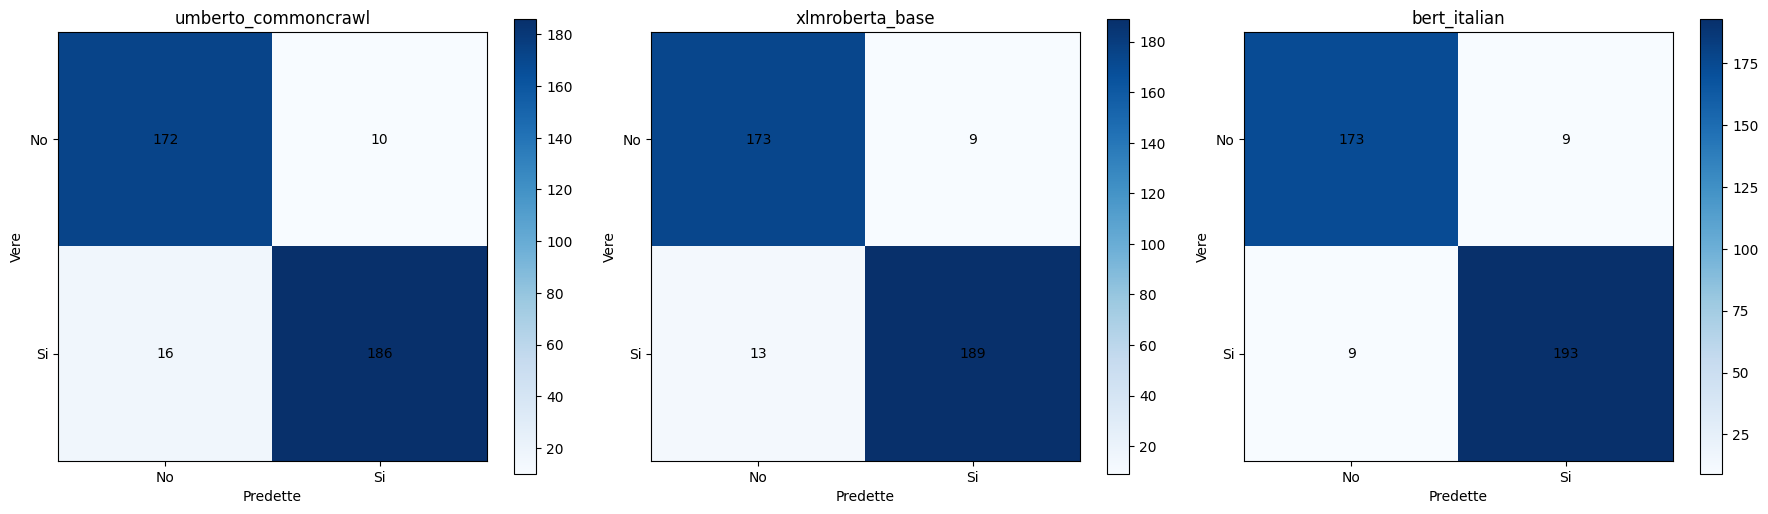

In [4]:
import os
import pickle
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.nn.functional import softmax
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# 0) Percorsi ai file su disco
METRICS_FILE = 'metrics_summary.csv'
CMS_FILE     = 'confusion_matrices.pkl'

# 1) Se i file esistono, ricarico e mostro, altrimenti computo tutto
if os.path.exists(METRICS_FILE) and os.path.exists(CMS_FILE):
    # --- caricamento ---
    df_metrics = pd.read_csv(METRICS_FILE, index_col=0)
    with open(CMS_FILE, 'rb') as f:
        cms = pickle.load(f)

    # --- stampa tabella ---
    print("=== Metriche aggregate caricate da disco ===\n")
    print(df_metrics.to_markdown(floatfmt=".4f"))

    # --- plot confusion matrix ---
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(6*n,5))
    for ax, (model, cm) in zip(axes, cms.items()):
        im = ax.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
        ax.set_title(model)
        ax.set_xticks([0,1]); ax.set_xticklabels(['No','Si'])
        ax.set_yticks([0,1]); ax.set_yticklabels(['No','Si'])
        ax.set_xlabel('Predette'); ax.set_ylabel('Vere')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i][j], ha='center', va='center')
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

else:
    # --- dati di validazione ---
    df_val = val_df  # il tuo DataFrame di validazione
    texts = df_val['conversation'].tolist()
    labels= df_val['toxic'].tolist()

    # --- modelli da valutare ---
    models_info = {
        'BERT':        './best_toxic_model',
        'UmBERTo':     './best_umberto',
        'XLM-RoBERTa': './best_xlmroberta',
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- dataset wrapper ---
    class ToxicDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_length=256):
            self.texts, self.labels = texts, labels
            self.tokenizer, self.max_length = tokenizer, max_length
        def __len__(self): return len(self.texts)
        def __getitem__(self, idx):
            enc = self.tokenizer(
                self.texts[idx],
                add_special_tokens=True,
                truncation=True,
                padding='max_length',
                max_length=self.max_length,
                return_tensors='pt'
            )
            return {
                'input_ids':      enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'label':          self.labels[idx]
            }

    results, cms = [], {}

    # --- loop di inferenza e calcolo metriche ---
    for name, path in models_info.items():
        print(f"\n=== {name} ===")
        tok = AutoTokenizer.from_pretrained(path, local_files_only=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(path, local_files_only=True).to(device)
        mdl.eval()

        ds     = ToxicDataset(texts, labels, tok)
        loader = DataLoader(ds, batch_size=32)

        all_preds, all_trues = [], []
        with torch.no_grad():
            for b in loader:
                iids = b['input_ids'].to(device)
                mask = b['attention_mask'].to(device)
                logits = mdl(input_ids=iids, attention_mask=mask).logits
                probs  = softmax(logits, dim=1)[:,1].cpu().numpy()
                preds  = (probs>0.5).astype(int).tolist()
                all_preds.extend(preds)
                all_trues.extend(b['label'])

        # report
        print(classification_report(all_trues, all_preds, digits=4, target_names=['No','Si']))

        # metriche aggregate
        acc  = accuracy_score(all_trues, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(
            all_trues, all_preds, average='binary', zero_division=0
        )
        cm = confusion_matrix(all_trues, all_preds)

        results.append({
            'model':     name,
            'accuracy':  acc,
            'precision': prec,
            'recall':    rec,
            'f1_score':  f1
        })
        cms[name] = cm

    # --- salvo metriche e matrici su disco ---
    df_metrics = pd.DataFrame(results).set_index('model')
    df_metrics.to_csv(METRICS_FILE)
    with open(CMS_FILE, 'wb') as f:
        pickle.dump(cms, f)

    print(f"\nSaved {METRICS_FILE} and {CMS_FILE}")

    # --- stampo e plotto subito come sopra ---
    print("\n=== Tabella confronto metriche ===")
    print(df_metrics.to_markdown(floatfmt=".4f"))

    fig, axes = plt.subplots(1, len(cms), figsize=(6*len(cms),5))
    for ax, (name, cm) in zip(axes, cms.items()):
        im = ax.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
        ax.set_title(name)
        ax.set_xticks([0,1]); ax.set_xticklabels(['No','Si'])
        ax.set_yticks([0,1]); ax.set_yticklabels(['No','Si'])
        ax.set_xlabel('Predette'); ax.set_ylabel('Vere')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i][j], ha='center', va='center')
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


In [5]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report
from torch.nn.functional import softmax
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# 1) Dataset wrapper per validazione
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

# 2) Impostazioni
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_paths = {
    'BERT':       './best_toxic_model',
    'UmBERTo':    './best_umberto',
    'XLM-RoBERTa':'./best_xlmroberta'
}
batch_size = 32
max_length = 256

# 3) Carico modelli e tokenizer
models, tokenizers = {}, {}
for name, path in model_paths.items():
    tokenizers[name] = AutoTokenizer.from_pretrained(path, local_files_only=True)
    models[name]     = AutoModelForSequenceClassification.from_pretrained(
                           path, local_files_only=True
                       ).to(device).eval()

# 4) Preparo DataLoader su validation set
texts = val_df['conversation'].tolist()
labels= val_df['toxic'].tolist()

dataset = TextDataset(texts, labels)
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# 5) Inferenza ensemble (soft voting)
y_true, y_pred = [], []

with torch.no_grad():
    for batch_texts, batch_labels in tqdm(loader, desc="Ensemble inferencing"):
        # per ogni modello calcolo i softmax(batch_size,)
        all_probs = []
        for name in model_paths:
            tok   = tokenizers[name]
            mdl   = models[name]
            enc   = tok(batch_texts,
                        padding='max_length',
                        truncation=True,
                        max_length=max_length,
                        return_tensors='pt').to(device)
            logits= mdl(**enc).logits
            probs = softmax(logits, dim=1)[:,1]       # prob tossicità
            all_probs.append(probs.cpu().numpy())

        # media sulle predizioni
        avg_probs = np.mean(all_probs, axis=0)
        batch_preds = (avg_probs > 0.5).astype(int).tolist()

        y_true.extend(batch_labels)
        y_pred.extend(batch_preds)

# 6) Report finale
print("\n=== Risultati Ensemble Voting (Soft) ===\n")
print(classification_report(y_true, y_pred,
                            target_names=['Non tossica','Tossica'],
                            digits=4))


Ensemble inferencing: 100%|██████████| 12/12 [00:08<00:00,  1.43it/s]


=== Risultati Ensemble Voting (Soft) ===

              precision    recall  f1-score   support

 Non tossica     0.9887    0.9669    0.9777       181
     Tossica     0.9710    0.9901    0.9805       203

    accuracy                         0.9792       384
   macro avg     0.9799    0.9785    0.9791       384
weighted avg     0.9794    0.9792    0.9792       384

